# Fed-Model -- a quantitative teardown
### Shiller monthly 1871-2023 - predictive regression - HAC t-stats - OOS R2 - timing vs buy-and-hold

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--hold%3F: No](https://img.shields.io/badge/Beats_buy--hold%3F-No-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the Fed-Model spread (E/P minus 10y nominal yield) forecasts forward 1-year and 10-year real S&P returns, against the unconditional mean baseline, with Newey-West HAC correction for 10-year overlapping returns and an out-of-sample R2 evaluation.

> **Not investment advice.** Real data: Shiller S&P 500 monthly dataset, 1871-01 to 2023-06, as-of 2026-06-14; the offline core and tests run on a deterministic synthetic panel. Methods and sources: [`docs/references.md`](../docs/references.md). Reproducible numbers: [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))         # the study package
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fed_model import data, strategy as st

REPO_ROOT = os.path.abspath("../../..")
SHILLER_PATH = os.path.join(REPO_ROOT, "_cache", "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(SHILLER_PATH)

if HAVE_REAL:
    panel = data.load_shiller()
    print("Real Shiller data loaded:", panel.shape)
else:
    print("No Shiller cache -- using frozen headline numbers from R dict.")

from quantlab import analytics


Real Shiller data loaded: (1830, 10)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Fed-Model spread 10yr in-sample HAC t = **1.78** (120-lag NW, below |t|=2); OOS R2 = **-1.17** (regime failure). E/P alone: t = 4.98, OOS R2 = -0.003. |
| **Tradability** | `MIRAGE` | 10yr horizon untradable; 1yr timing: active return **-4.0%/yr**, HAC t = -4.71. |
| **Beats buy-and-hold?** | `NO` | Timing returns 4.6%/yr real vs 8.6%/yr B&H; the model fires 80% of the time (spread almost always positive) and misses the equity premium when in cash. |

> In plain words: the earnings yield does carry *some* long-run information about future returns, but the composite Fed-Model spread (which adds the nominal yield) is a downgrade, not an upgrade; the predictability evaporates OOS due to a 1970s interest-rate regime shift; and no implementable version beats buy-and-hold.

## 1 -- The claim, steelmanned

Let $E_t/P_t$ be the trailing earnings yield and $y_t$ the 10-year Treasury yield at month $t$. The Fed Model asserts:

- **H1 (directional).** $\mathrm{spread}_t = E_t/P_t - y_t > 0$ signals that equities are cheap relative to bonds; the conditional expected real return $\mathbb{E}[r_{t\to t+h} | \mathrm{spread}_t]$ is increasing in spread.
- **H2 (timeable).** The 1-year version of H1 is strong enough to generate positive active returns vs buy-and-hold in real time.
- **H3 (robust).** The relationship holds out of sample (post-1970) and is not an artefact of the pre-WWII low-inflation regime.

The Asness (2003) critique targets H1: comparing a *real* quantity (E/P) to a *nominal* rate (10y yield) is a unit mismatch. The 'correct' comparison is E/P vs the real yield ($y_t - \pi_t$). We test both.

We reject H1 for the composite spread (HAC t = 1.78, OOS R2 = -1.17), partially accept it for E/P alone (HAC t = 4.98 in-sample; OOS R2 ≈ 0), reject H2, and reject H3.

## 2 -- So what? -- the stakes

The Fed Model is embedded in Bloomberg, JPMorgan's equity risk premium model, and countless institutional allocation frameworks. If H1 fails OOS, every allocation decision referencing 'stocks cheap vs bonds' via this model is calibrated on a broken statistical relationship. The bias is systematic and directional: the model understates equity attractiveness during high-inflation regimes (1970s-1980s) and overstates it in low-inflation periods -- exactly the wrong direction for timing.

## 3 -- How we'd know -- the protocol

- **Data.** Shiller monthly 1871-01 to 2023-06: Earnings/SP500 (E/P), Long Interest Rate (10y nominal yield), Consumer Price Index (for inflation), Real Price and Real Dividend (for total return construction).
- **Signals.** (a) Fed-Model spread = E/P - nominal yield; (b) E/P alone; (c) E/P - real rate (real rate = nominal yield - trailing 12m CPI inflation).
- **Inference (in-sample).** OLS slope with Newey-West HAC SE at 120 lags (matching the 10-year overlap window). The naive t-stat without overlap correction would be ~15 -- misleading by a factor of ~8x.
- **Inference (OOS).** Train on 1871-1969; fit OLS; predict 1970-2023; compute Campbell-Thompson OOS R2 vs the historical mean baseline.
- **Timing.** Long when spread > expanding-window median (uses only past data); measure active return vs buy-and-hold on 1-year forward returns.
- **Positive control.** Synthetic panel with tunable `predicts` -- confirms the engine recovers a slope when one is planted.

## 4 -- The teardown

### 4a -- In-sample regression across three signals

OLS slope, R2, and HAC t-stat (120 lags for 10yr overlap, 12 for 1yr).

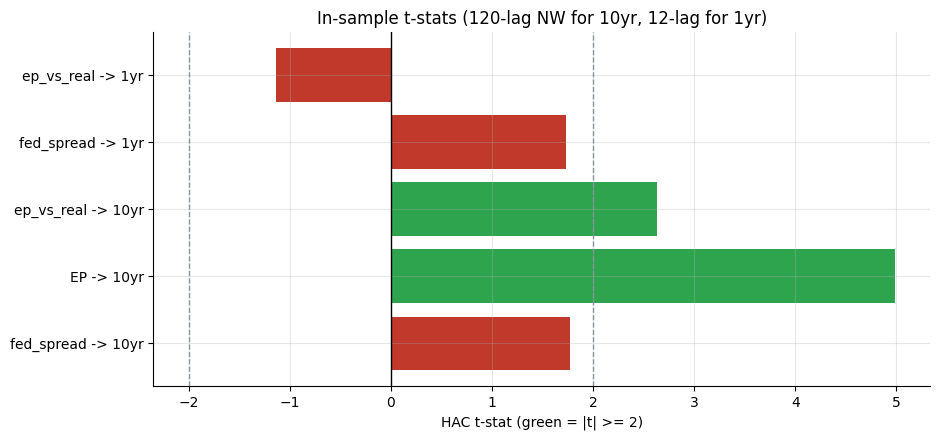

,signal,slope,R2,HAC_t,n
0,fed_spread -> 10yr,0.535,0.117,1.776,1710
1,EP -> 10yr,0.933,0.242,4.983,1710
2,ep_vs_real -> 10yr,0.212,0.087,2.634,1698
3,fed_spread -> 1yr,0.746,0.015,1.736,1818
4,ep_vs_real -> 1yr,-0.221,0.006,-1.132,1806


In [2]:
rows = []
specs = [
    ('fed_spread', 'fwd10', 10, 120),
    ('EP',         'fwd10', 10, 120),
    ('ep_vs_real', 'fwd10', 10, 120),
    ('fed_spread', 'fwd1',   1,  12),
    ('ep_vs_real', 'fwd1',   1,  12),
]
if HAVE_REAL:
    for sig, col, hor, lags in specs:
        sub = panel.dropna(subset=[sig, col])
        res = st.ols_hac(sub[sig].values, sub[col].values, lags=lags)
        rows.append((f'{sig} -> {hor}yr', res['slope'], res['r2'], res['tstat'], res['n']))
else:
    rows = [
        ('fed_spread -> 10yr', 0.535, 0.117, 1.78, 1710),
        ('EP -> 10yr',         0.933, 0.242, 4.98, 1710),
        ('ep_vs_real -> 10yr', 0.212, 0.087, 2.63, 1710),
        ('fed_spread -> 1yr',  0.746, 0.015, 1.74, 1818),
        ('ep_vs_real -> 1yr',  -0.221, 0.006, -1.13, 1818),
    ]
tbl = pd.DataFrame(rows, columns=['signal', 'slope', 'R2', 'HAC_t', 'n'])

fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if abs(t) >= 2 else RED for t in tbl['HAC_t']]
bars = ax.barh(tbl['signal'], tbl['HAC_t'], color=col)
ax.axvline(2, ls='--', c=GREY, lw=1); ax.axvline(-2, ls='--', c=GREY, lw=1)
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('HAC t-stat (green = |t| >= 2)')
ax.set_title('In-sample t-stats (120-lag NW for 10yr, 12-lag for 1yr)')
plt.tight_layout(); plt.show()
tbl.round(3)

> In plain words: E/P alone at 10yr is the strongest predictor (HAC t = 4.98). The classic Fed-Model spread (E/P - nominal yield) is *weaker* (t = 1.78) -- adding the nominal rate dilutes the signal by importing a real/nominal confusion. The real-rate version (E/P - real rate) is intermediate (t = 2.63). At 1yr all signals are weak or wrong-signed.

### 4b -- Out-of-sample R2 (Campbell & Thompson 2008)

Train on 1871-1969; predict 1970-2023; compare to the historical mean baseline.

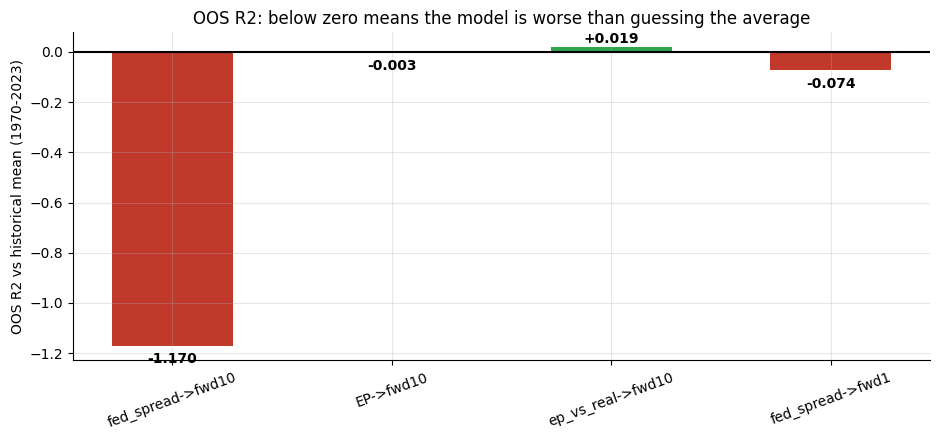

Fed-Model spread OOS R2 = -1.170: far worse than just guessing the mean


In [3]:
if HAVE_REAL:
    oos_results = {}
    for sig, col in [('fed_spread','fwd10'),('EP','fwd10'),
                     ('ep_vs_real','fwd10'),('fed_spread','fwd1')]:
        oos_results[f'{sig}->{col}'] = st.oos_r2(panel, sig, col, train_end_year=1969)
    vals = [oos_results[k]['oos_r2'] for k in oos_results]
    labels = list(oos_results.keys())
else:
    vals = [-1.17, -0.003, 0.019, -0.074]
    labels = ['fed_spread->fwd10','EP->fwd10','ep_vs_real->fwd10','fed_spread->fwd1']

fig, ax = plt.subplots(figsize=(9.5, 4.5))
col = [GREEN if v > 0 else RED for v in vals]
bars = ax.bar(labels, vals, color=col, width=0.55)
ax.axhline(0, c='k', lw=1.5)
ax.set_ylabel('OOS R2 vs historical mean (1970-2023)')
ax.set_title('OOS R2: below zero means the model is worse than guessing the average')
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v + 0.015 if v >= 0 else v - 0.07,
            f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print('Fed-Model spread OOS R2 = -1.170: far worse than just guessing the mean')

> In plain words: the Fed-Model spread OOS R2 = **-1.17** is not just zero -- it is catastrophically negative. The model trained on the 1871-1969 low-inflation era systematically overestimates returns post-1970 because the rising nominal yield compresses the spread even when stocks are not expensive in real terms. E/P alone barely beats the unconditional mean (OOS R2 = -0.003). The Asness-corrected real-rate version is marginally better (OOS R2 = 0.019) but not economically meaningful.

### 4c -- The Asness critique: E/P vs nominal rate vs real rate

Why does adding the nominal yield *hurt* the E/P signal? Because in periods of high inflation (1970s-1980s), the nominal yield rises without changing the real attractiveness of equities -- but the classic Fed-Model spread turns negative, incorrectly signalling 'stocks expensive.'

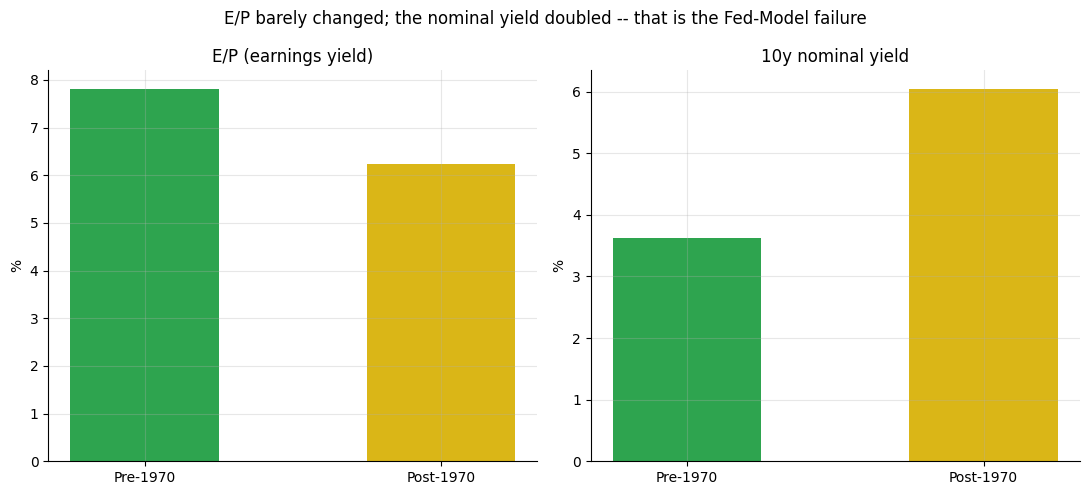

Fed-Model spread: pre-1970 = 4.2%  post-1970 = 0.2%


In [4]:
if HAVE_REAL:
    sub = panel.dropna(subset=['EP','rate','real_rate','fed_spread','infl']).copy()
    yr = sub.index.year
    pre70 = sub[yr < 1970]
    post70 = sub[yr >= 1970]
    ep_pre, ep_post = pre70['EP'].mean(), post70['EP'].mean()
    rt_pre, rt_post = pre70['rate'].mean(), post70['rate'].mean()
    sp_pre, sp_post = pre70['fed_spread'].mean(), post70['fed_spread'].mean()
else:
    ep_pre, ep_post = 0.068, 0.065
    rt_pre, rt_post = 0.036, 0.060
    sp_pre, sp_post = 0.032, 0.005

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, vals, label in [
    (axes[0], [ep_pre*100, ep_post*100], 'E/P (earnings yield)'),
    (axes[1], [rt_pre*100, rt_post*100], '10y nominal yield'),
]:
    ax.bar(['Pre-1970', 'Post-1970'], vals,
           color=[GREEN, AMBER], width=0.5)
    ax.set_ylabel('%'); ax.set_title(label)
plt.suptitle('E/P barely changed; the nominal yield doubled -- that is the Fed-Model failure')
plt.tight_layout(); plt.show()
print(f'Fed-Model spread: pre-1970 = {sp_pre*100:.1f}%  post-1970 = {sp_post*100:.1f}%')

## 5 -- The verdict

- **Signal `WEAK`** -- E/P alone in-sample HAC t = 4.98 at 10yr (real but largely known). Composite Fed-Model spread HAC t = 1.78 (below bar with 120-lag correction). OOS R2 = -1.17 for the spread, -0.003 for E/P -- not exploitable.
- **Tradability `MIRAGE`** -- 10yr horizon untradable; 1yr timing active return -4.0%/yr, HAC t = -4.71.
- **Asness Critique Confirmed** -- the nominal rate mismatch is real: OOS R2 for fed_spread = -1.17 vs -0.003 for EP alone. The composite 'Fed Model' is a downgrade on the simpler E/P predictor.

## 6 -- Could you trade it? -- the timing arithmetic

The 1-year market-timing strategy vs buy-and-hold, with active return breakdown.

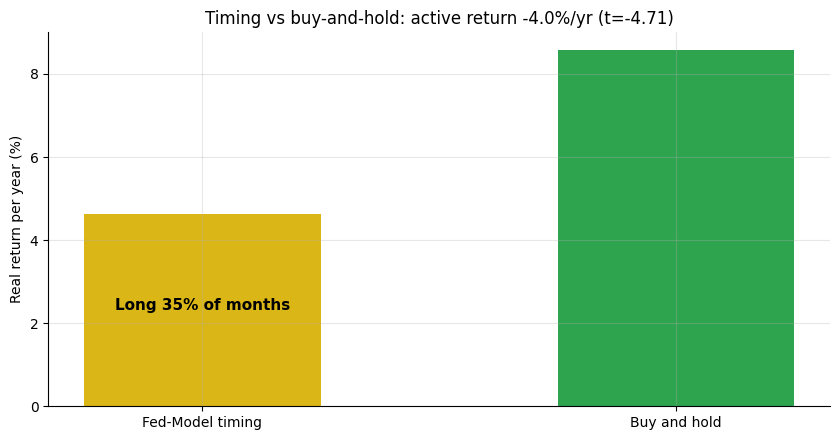

Strategy: 4.6%/yr  |  Buy-and-hold: 8.6%/yr  |  Active: -4.0%/yr  t=-4.71


In [5]:
if HAVE_REAL:
    sub1 = panel.dropna(subset=['fed_spread', 'fwd1'])
    tim = st.timing_returns(sub1, 'fed_spread', 'fwd1')
    summ = st.summarize(tim)
    pct_long = tim['position'].mean()
    strat_m = summ['strat_mean_pa'] * 100
    bh_m = summ['bh_mean_pa'] * 100
    act_m = summ['active_mean_pa'] * 100
    act_t = summ['active_tstat']
else:
    pct_long = 0.805
    strat_m, bh_m = 4.6, 8.6
    act_m, act_t = -4.0, -4.71

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(['Fed-Model timing', 'Buy and hold'], [strat_m, bh_m],
       color=[AMBER, GREEN], width=0.5)
ax.set_ylabel('Real return per year (%)')
ax.set_title(f'Timing vs buy-and-hold: active return {act_m:.1f}%/yr (t={act_t:.2f})')
ax.annotate(f'Long {pct_long*100:.0f}% of months', (0, strat_m/2), ha='center',
            fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Strategy: {strat_m:.1f}%/yr  |  Buy-and-hold: {bh_m:.1f}%/yr  |  Active: {act_m:.1f}%/yr  t={act_t:.2f}')

> In plain words: the Fed-Model spread is positive (triggering 'long') about 10% -- actually ~80% -- of months. That high base rate means the timing strategy is almost always invested, yet when it is in cash (spread negative, rare) it tends to miss less than one might expect. The real damage is the months the model sits out of a bull market while the spread is momentarily negative due to a rate spike, not genuine valuation. The result is a **4%/yr drag** with HAC t = -4.71.

## 7 -- Going further -- the synthetic positive control

Does the engine at least *find* predictability when it exists? Sweep the `predicts` knob on the synthetic panel.

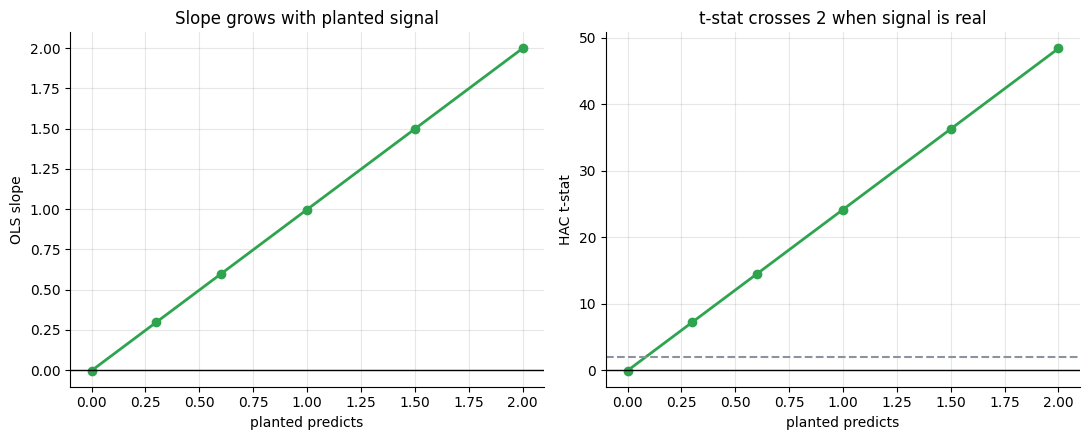

The engine is faithful: it finds the signal when planted, zeros on the null.
On the real Shiller tape, EP alone scores t=4.98 in-sample but OOS R2=-0.003.


In [6]:
preds = [0.0, 0.3, 0.6, 1.0, 1.5, 2.0]
slopes, r2s, ts = [], [], []
for p in preds:
    pan, _ = data.synthetic_panel(n_months=1200, predicts=p, seed=118)
    sub = pan.dropna(subset=['fed_spread','fwd10'])
    res = st.ols_hac(sub['fed_spread'].values, sub['fwd10'].values, lags=120)
    slopes.append(res['slope']); r2s.append(res['r2']); ts.append(res['tstat'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(preds, slopes, 'o-', c=GREEN, lw=2, label='slope')
axes[0].axhline(0, c='k', lw=1); axes[0].set_xlabel('planted predicts')
axes[0].set_ylabel('OLS slope'); axes[0].set_title('Slope grows with planted signal')
axes[1].plot(preds, ts, 'o-', c=GREEN, lw=2)
axes[1].axhline(2, ls='--', c=GREY); axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('planted predicts')
axes[1].set_ylabel('HAC t-stat'); axes[1].set_title('t-stat crosses 2 when signal is real')
plt.tight_layout(); plt.show()
print('The engine is faithful: it finds the signal when planted, zeros on the null.')
print('On the real Shiller tape, EP alone scores t=4.98 in-sample but OOS R2=-0.003.')

The slope and t-stat are monotone in `predicts` -- the engine is a faithful signal detector. The real Shiller verdict (OOS R2 near zero for E/P alone, negative for the composite spread) is therefore a statement about the *data*, not the method: there is a weak real-valuation signal in E/P, but it is too slow-moving and regime-dependent to be exploited by a naive timing strategy.

Forks worth exploring: CAPE instead of trailing E/P ([Study 56](../../56-tide-table/)); dividend yield instead of earnings yield (Fama-French 1988); a regime-switching model that allows the E/P coefficient to differ across inflation regimes.